# Employee Attrition Analysis

## Problem Statement

Employee attrition is a major challenge for organizations. High attrition leads to increased recruitment costs, productivity loss, and knowledge drain.

The objective of this project is to analyze HR data and identify factors affecting employee attrition using exploratory data analysis and machine learning techniques.

## Project Objectives

• Understand HR dataset structure  
• Clean and preprocess data  
• Perform exploratory data analysis  
• Identify important attrition factors  
• Prepare dataset for ML modeling

### Import Required Libraries

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

### Load dataset

In [4]:
df = pd.read_csv("data/HR_Analytics.csv")

In [5]:
# Display first 5 rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Initial Data Inspection

In [6]:
# Dataset shape
print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 35)


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [9]:
# Statistical summary
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
# Check categorical summary
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## Data Cleaning
In this step we prepare the dataset for analysis by:
- Checking missing values
- Removing duplicate records
- Removing irrelevant features
- Preparing useful features for modeling  

In [11]:
# Check null values
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

#### Observation:
No missing values found in the dataset.
Dataset is clean in terms of null values.

In [12]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

In [13]:
# Check unique values per column
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [14]:
# Drop constant columns
df = df.drop(['EmployeeCount','EmployeeNumber','Over18','StandardHours'], axis=1)

EmployeeCount → always 1, Over18 → always Y, StandardHours → always 80

These have zero variance → useless for ML.

EmployeeNumber-IDs do not help prediction.

In [15]:
df.shape

(1470, 31)

In [16]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StockOptionLevel             int64
TotalWorkingYears            int64
TrainingTimesLastYear        int64
WorkLifeBalance              int64
YearsAtCompany               int64
YearsInCurrentRole  

In [17]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [18]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

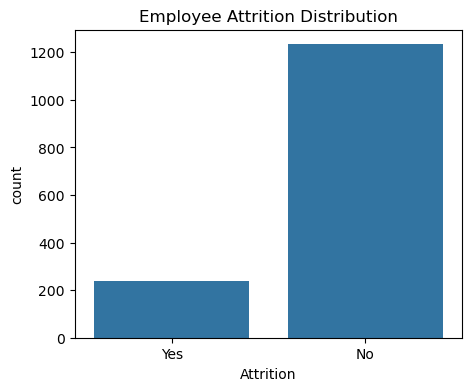

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

In [20]:
num_cols = df.select_dtypes(include=['int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 23
Categorical columns: 8


#### Data Cleaning Observations
- No missing values found
- No duplicate records detected
- Removed constant columns:
  - EmployeeCount
  - Over18
  - StandardHours
- Removed identifier column:
  - EmployeeNumber
- Final dataset contains 31 useful features.

The dataset is now ready for exploratory data analysis.

## Exploratory Data Analysis (EDA)
In this section we analyze important HR features using barplots to identify patterns affecting employee attrition.

In [21]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

## Attrition Distribution

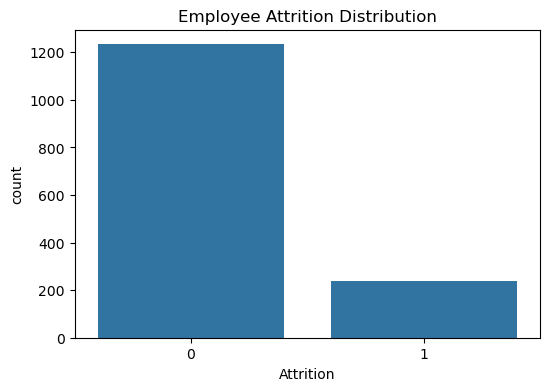

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Employee Attrition Distribution")
plt.show()

### Insight:
- Majority of employees did not leave the company
- Only a small portion of employees left
- Dataset shows class imbalance  

## Attrition vs Department

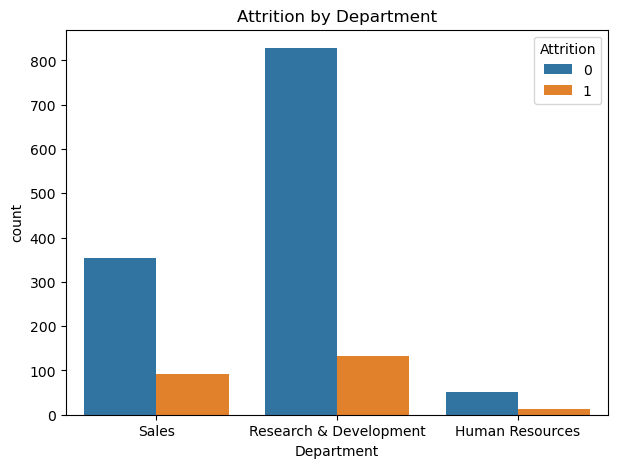

In [23]:
plt.figure(figsize=(7,5))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.title("Attrition by Department")
plt.xticks(rotation=0)
plt.show()

### Insight:
- Research & Development department has highest employees
- Sales department shows noticeable attrition
- HR department has lowest employees  

## Attrition vs Gender

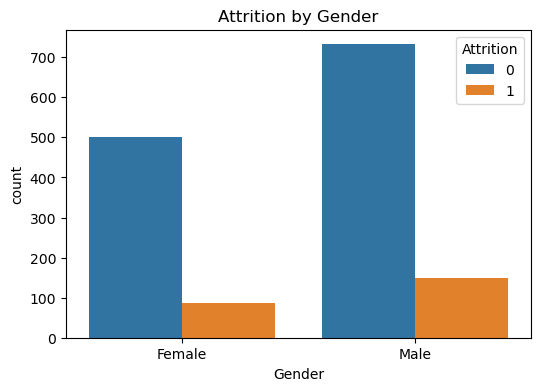

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title("Attrition by Gender")
plt.show()

### Insight:
- Male employees are more in number
- Attrition appears slightly higher among males  

## Attrition vs Job Role

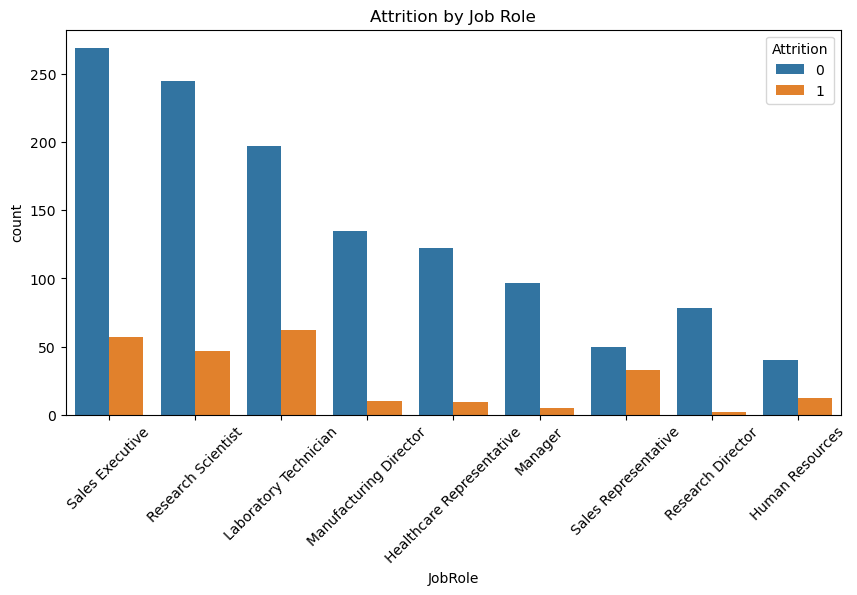

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.title("Attrition by Job Role")
plt.xticks(rotation=45)
plt.show()

### Insight:
- Sales Executives and Laboratory Technicians show higher attrition
- Manager roles show lower attrition
- Entry level roles show higher turnover

## Attrition vs Overtime

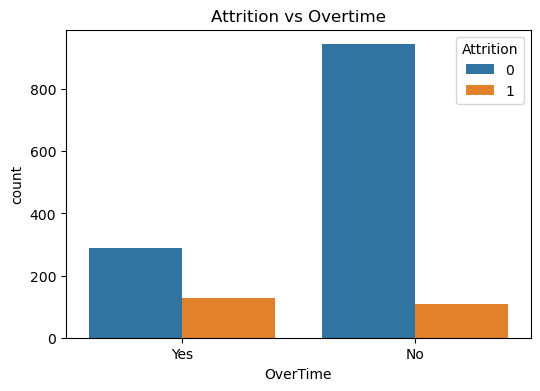

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

### Insight:
- Employees working overtime show significantly higher attrition
- Workload may be a major factor affecting employee retention

## Attrition vs Marital Status

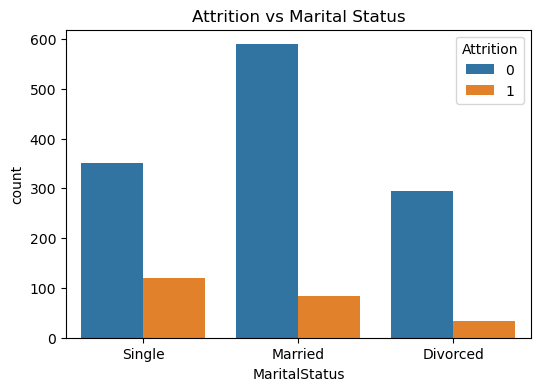

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title("Attrition vs Marital Status")
plt.show()

### Insight:
- Single employees show higher attrition
- Married employees show better retention

## Attrition vs Education Field

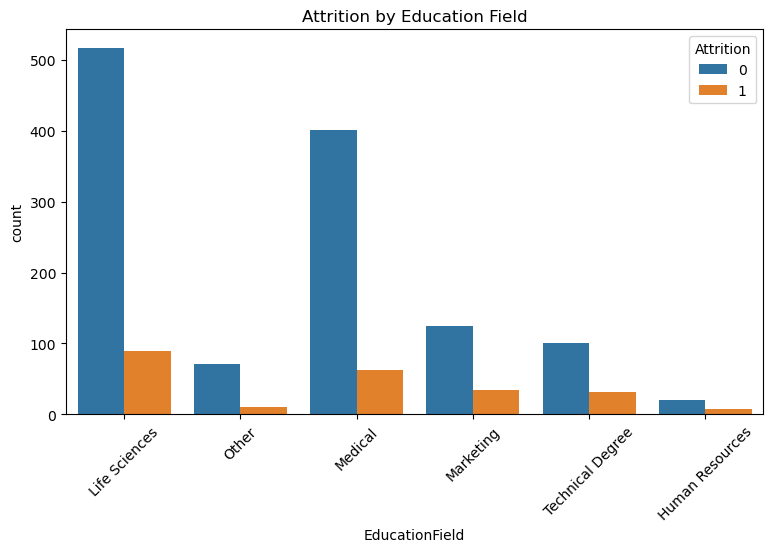

In [28]:
plt.figure(figsize=(9,5))
sns.countplot(x='EducationField', hue='Attrition', data=df)
plt.title("Attrition by Education Field")
plt.xticks(rotation=45)
plt.show()

### Insight:
- Life Sciences and Medical field people show higher attrition

## Attrition vs Job Level

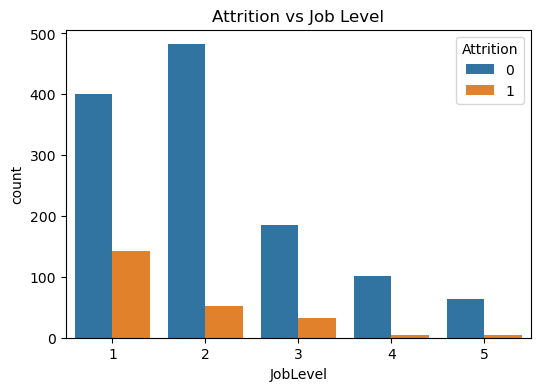

In [29]:
plt.figure(figsize=(6,4))
sns.countplot(x='JobLevel', hue='Attrition', data=df)
plt.title("Attrition vs Job Level")
plt.show()

### Insight:
- Lower job levels show higher attrition
- Senior employees show better retention

## Attrition vs Business Travel

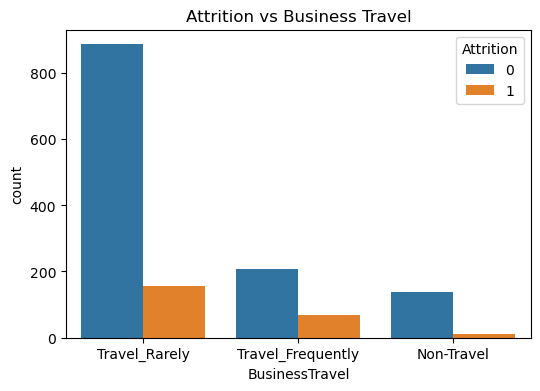

In [30]:
plt.figure(figsize=(6,4))
sns.countplot(x='BusinessTravel', hue='Attrition', data=df)
plt.title("Attrition vs Business Travel")
plt.show()

### Insight:
- Travel rarely employees shows the higher attrition
- Non Travel employees shows the lesser attrition

In [31]:
# Attrition percentage by overtime
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')*100

Attrition,0,1
OverTime,,
No,89.563567,10.436433
Yes,69.471154,30.528846


## Attrition vs Monthly Income

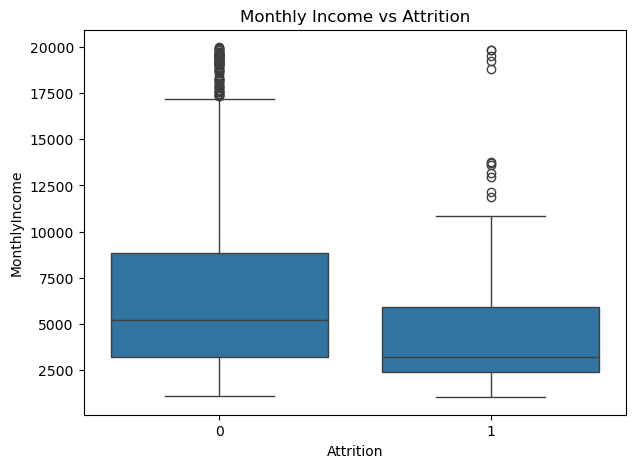

In [32]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

## Correlation Heatmap

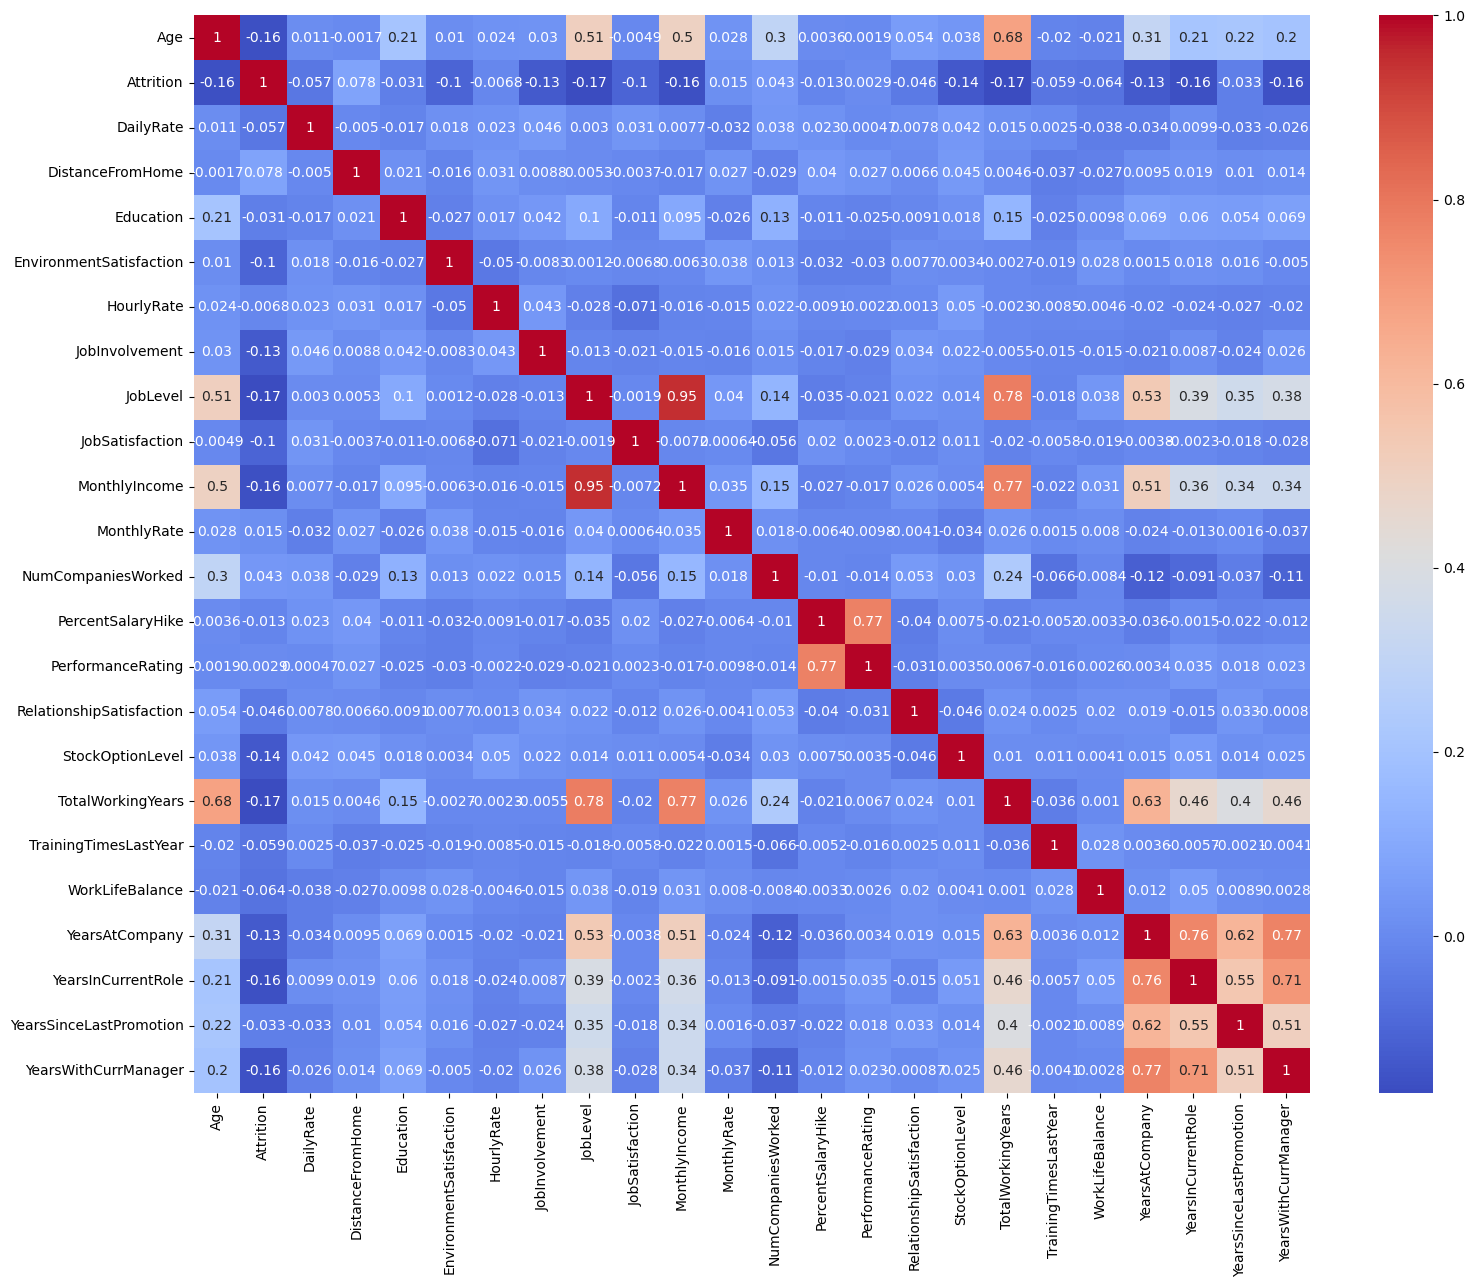

In [33]:
plt.figure(figsize=(18,14))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

## Machine Learning Models
In this section we train classification models to predict employee attrition.

Models used:
- Logistic Regression
- Decision Tree
- Random Forest  

First we begin with Logistic Regression.

### Prepare features and target

In [36]:
# Features and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

### Encode categorical variables

In [37]:
# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

### Train Test Split

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

### Feature Scaling

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Logistic Regression Model

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
cr = classification_report(y_test,y_pred)

print("Logistic Regression Accuracy:", accuracy)

print("\nClassification Report:\n")
print(cr)

print("\nConfusion Matrix:\n")
print(cm)

Logistic Regression Accuracy: 0.8775510204081632

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.55      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294


Confusion Matrix:

[[241  14]
 [ 22  17]]


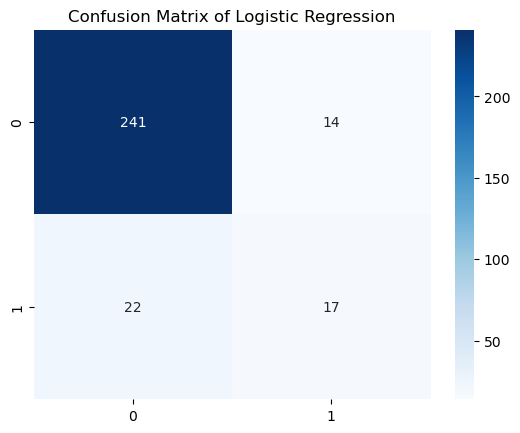

In [44]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix of Logistic Regression")
plt.show()

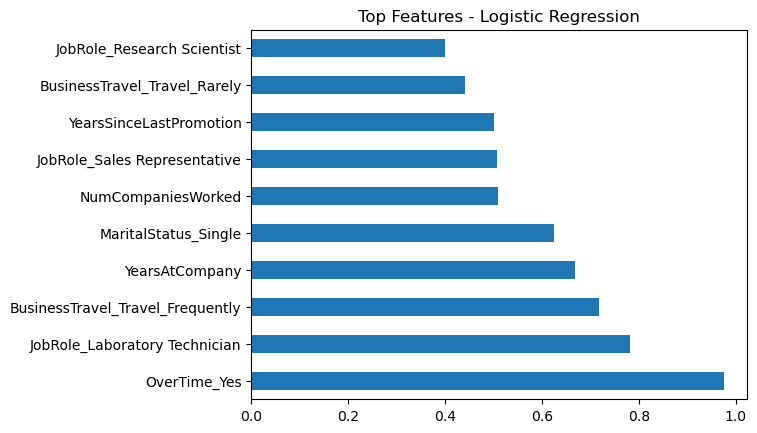

In [76]:
importance_lr = pd.Series(lr_model.coef_[0],
                       index=X.columns)

importance_lr.sort_values(
    ascending=False
).head(10).plot(
    kind='barh'
)

plt.title("Top Features - Logistic Regression")
plt.show()

### Insights:
The Logistic Regression model achieved an accuracy of 87.75%, indicating strong overall classification performance.
- Model performs very well in predicting employees who stay.
- Model struggles to identify employees who leave due to class imbalance.
- Recall for attrition class is relatively low (44%).
- Some attrition cases are misclassified as non-attrition.


## Decision Tree Model

Decision Tree is a supervised machine learning algorithm that makes predictions by splitting data based on feature importance. It is useful for identifying key factors affecting employee attrition.

In [50]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10
)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test,y_pred_dt)
cm = confusion_matrix(y_test,y_pred_dt)
cr = classification_report(y_test,y_pred_dt)

print("Decision Tree Accuracy:", accuracy)

print("\nClassification Report:\n")
print(cr)

print("\nConfusion Matrix:\n")
print(cm)

Decision Tree Accuracy: 0.8197278911564626

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       255
           1       0.23      0.15      0.18        39

    accuracy                           0.82       294
   macro avg       0.55      0.54      0.54       294
weighted avg       0.79      0.82      0.80       294


Confusion Matrix:

[[235  20]
 [ 33   6]]


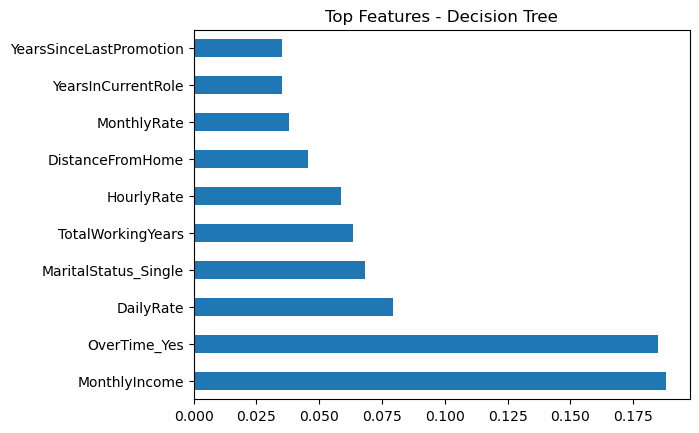

In [71]:
importance_dt = pd.Series(dt_model.feature_importances_,
                       index=X.columns)

importance_dt.sort_values(
    ascending=False
).head(10).plot(
    kind='barh'
)

plt.title("Top Features - Decision Tree")
plt.show()

### Insights:
The Decision Tree model achieved an accuracy of 81.92%, which is lower than the Logistic Regression model.
- Model performs reasonably for predicting employees who stay.
- Model performs poorly in identifying employees who leave.
- Recall for attrition class is very low (18%).
- Model misses many attrition cases.

The Decision Tree model is less effective than Logistic Regression for this dataset. Further tuning or ensemble methods may improve performance.

## Random Forest Model
Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model is expected to perform better than a single decision tree due to averaging of multiple models.

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test,y_pred_rf)
cm = confusion_matrix(y_test,y_pred_rf)
cr = classification_report(y_test,y_pred_rf)

print("Random Forest Accuracy:", accuracy)

print("\nClassification Report:\n")
print(cr)

print("\nConfusion Matrix:\n")
print(cm)

Random Forest Accuracy: 0.8775510204081632

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294


Confusion Matrix:

[[254   1]
 [ 35   4]]


### Insights:
The Random Forest model achieved an accuracy of 87.75%, comparable to Logistic Regression.
- Model performs extremely well for predicting employees who stay.
- Model performs poorly in identifying employees who leave.
- Attrition recall is very low (10%).
- Model misses many attrition cases.

Although Random Forest shows high accuracy, Logistic Regression performs better in identifying attrition cases, which is more important for business decision making.

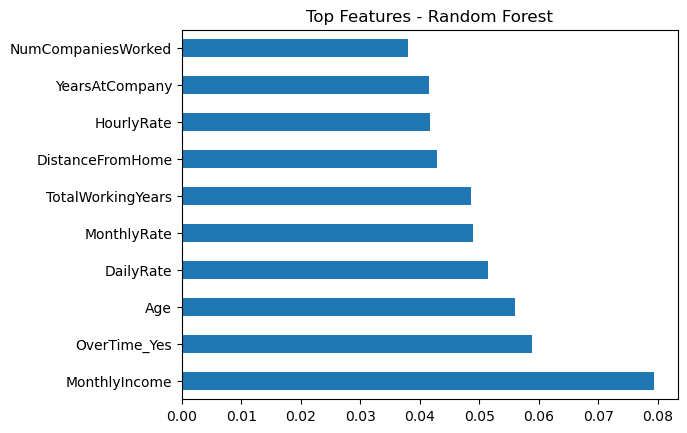

In [80]:
importance_rf = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance_rf.sort_values(
    ascending=False
).head(10).plot(
    kind='barh'
)

plt.title("Top Features - Random Forest")
plt.show()

## ROC Curve Comparison of Machine Learning Models
Receiver Operating Characteristic (ROC) curve is used to evaluate classification model performance.  
It shows the trade-off between True Positive Rate and False Positive Rate.

In this section we compare:
- Logistic Regression
- Decision Tree
- Random Forest
  
The model with higher AUC performs better.

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression ROC
y_prob_lr = lr_model.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Decision Tree ROC
y_prob_dt = dt_model.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# Random Forest ROC
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# Print ROC scores
print("ROC AUC Scores:")
print("Logistic Regression:", roc_auc_lr)
print("Decision Tree:", roc_auc_dt)
print("Random Forest:", roc_auc_rf)

ROC AUC Scores:
Logistic Regression: 0.7902463549522373
Decision Tree: 0.5820512820512821
Random Forest: 0.7517848164906988


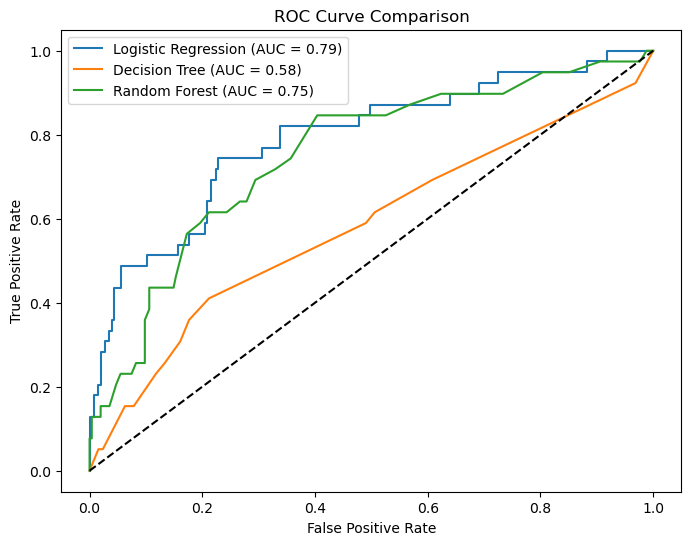

In [59]:
# Plot ROC Curves
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label="Logistic Regression (AUC = %0.2f)" % roc_auc_lr)

plt.plot(fpr_dt, tpr_dt,
         label="Decision Tree (AUC = %0.2f)" % roc_auc_dt)

plt.plot(fpr_rf, tpr_rf,
         label="Random Forest (AUC = %0.2f)" % roc_auc_rf)

# Random guess line
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

### Insight:
The ROC curve compares the classification performance of Logistic Regression, Decision Tree, and Random Forest models based on their ability to distinguish between employees who leave and those who stay.
- Logistic Regression shows the best performance among all models.
- Random Forest shows good performance but slightly lower than Logistic Regression.
- Decision Tree shows the weakest performance.
- Logistic Regression curve is closest to the top-left corner, indicating better classification ability.

A higher ROC AUC score indicates better model performance. Logistic Regression achieves the highest AUC score, meaning it has the best ability to distinguish between attrition and non-attrition employees.

## Model Comparison

In [78]:
model_comparison = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest'],
    'Accuracy':[0.877,0.819,0.877],
    'ROC Score':[0.79,0.58,0.75]
})

model_comparison

,Model,Accuracy,ROC Score
0,Logistic Regression,0.877,0.79
1,Decision Tree,0.819,0.58
2,Random Forest,0.877,0.75


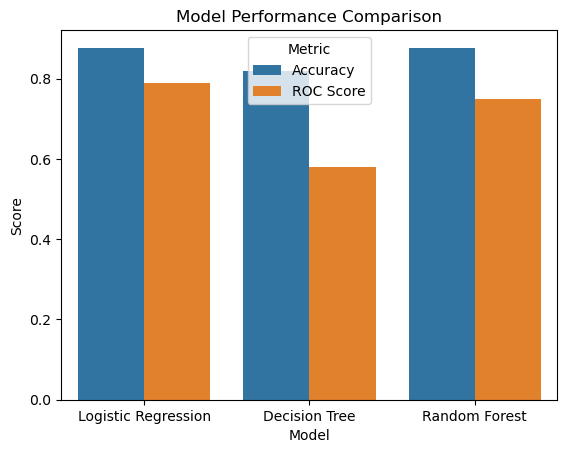

In [63]:
model_comparison_melted = model_comparison.melt(
    id_vars='Model',
    value_vars=['Accuracy','ROC Score'],
    var_name='Metric',
    value_name='Score'
)

sns.barplot(x='Model', y='Score', hue='Metric',
            data=model_comparison_melted)

plt.title("Model Performance Comparison")

plt.show()

In [85]:
best_model = lr_model
print("Final Selected Model:", best_model)

Final Selected Model: LogisticRegression()


## Final Model Selection
After evaluating Logistic Regression, Decision Tree, and Random Forest models using accuracy and ROC analysis, Logistic Regression was selected as the final model.

### Reasons:
- Highest ROC score
- Balanced classification performance
- Better detection of attrition cases
- Stable predictions

### Final Decision:
Logistic Regression is selected as the final model for employee attrition prediction.

## Conclusion:
Logistic Regression is selected as the final predictive model for employee attrition analysis because it provides the best balance between predictive accuracy and attrition detection capability.

This model can help organizations identify at-risk employees and take proactive retention measures.

## Prediction System

In [88]:
def predict_attrition(input_data):
    input_df = pd.DataFrame([input_data])
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(
        columns=X.columns,
        fill_value=0
    )

    input_scaled = scaler.transform(input_df)
    prediction = best_model.predict(input_scaled)

    if prediction[0] == 1:
        return "Employee likely to leave"
    else:
        return "Employee likely to stay"

In [90]:
sample_employee = X.iloc[1]
predict_attrition(sample_employee)

'Employee likely to stay'

## Save the model

In [ ]:
import joblib

joblib.dump(lr_model,"models/attrition_model.pkl")
joblib.dump(scaler,"models/scaler.pkl")
joblib.dump(X.columns,"models/model_columns.pkl")

print("Model saved successfully")

Model saved successfully


## Project Conclusion
This project successfully developed a machine learning model to predict employee attrition using HR analytics data.

### Work completed:
- Data Cleaning
- Exploratory Data Analysis
- Model Training
- Model Comparison
- ROC Analysis
- Final Model Selection
- Model Saving

### Final Result:
Logistic Regression was selected as the final model with:

Accuracy: 87.75%
ROC Score: 0.79

### Key Learning:
This project demonstrated the importance of comparing multiple models and selecting the best performing model based on evaluation metrics.

The model can help organizations identify employees at risk and improve retention strategies.